# Luyoa — Exploratory Data Analysis (EDA)
### Proyecto Integrador · Maestría en Inteligencia Artificial Aplicada · Tecnológico de Monterrey

| Campo | Detalle |
|---|---|
| **Empresa** | Luyoa — Digital loyalty card platform (Spain & Mexico) |
| **Variable objetivo** | `businesses.active` — B2B churn: ¿el negocio suscrito a Luyoa sigue activo? |
| **Sponsor** | Gabriela Soria, Luyoa |
| **Integrantes** | Sergio Sebastián Guzman Guerrero A01370820, Enrique Correa Herrerías A01332620, Nicolás Felipe Araque Araque A01795483|
| **Dataset** | Datos sintéticos generados mediante data augmentation (Anexo 1 — EsquemaBBDD_Luyoa) |
| **Periodo de análisis** | Últimos 2 años |

---

## Estructura del notebook

1. Configuración y carga de datos  
2. **Sección A — Feature Engineering desde tablas raw** *(path para datos reales de Luyoa)*  
3. Análisis univariante  
4. Análisis bivariante / multivariante  
5. Valores faltantes y patrones de ausencia  
6. Valores atípicos (outliers)  
7. Cardinalidad de variables categóricas  
8. Distribuciones, sesgo y transformaciones  
9. Tendencias temporales  
10. Correlaciones  
11. Balance de clases (variable objetivo)  
12. Preprocesamiento final  
13. **Sección B — Anexo metodológico: uso de churn_master_table sintética**  
14. Conclusiones del EDA

> ⚠️ **Nota metodológica:** La Sección A es el camino obligatorio para datos reales.  
> La Sección B documenta el uso de la tabla feature-engineered sintética y es opcional.


## 0. Configuración y librerías

In [ ]:
pip install missingno

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr



try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False
    print("missingno not installed — missing value matrix will use fallback.")

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE_BINARY = ['#2196F3', '#F44336']   # active=blue, inactive=red
PALETTE_CAT    = sns.color_palette('tab10')
sns.set_theme(style='whitegrid', palette='tab10')

print("Libraries loaded.")

In [ ]:
# ── CONFIGURACIÓN DE RUTA ────────────────────────────────────────────────────────
# Incluir dirección de la carpeta ZIP con el conjunto de datos
DATA_DIR = r'C:\Users\ASUS1\OneDrive - Vlogos Analytics (1)\Grupo AR\Respaldos Nicolás\MNA Tec Monterrey\Proyecto Integrador\Entregas\Avance 1. Análisis Exploratorio EDA\luyoa_v2_datasets\luyoa_v2'          # <-- Ajustar aquí

def load(table):
    """Cargar las tablas de Luyoa en CSV hacia a DataFrame."""
    path = os.path.join(DATA_DIR, f'{table}.csv')
    return pd.read_csv(path, low_memory=False)

# ── LOAD ALL TABLES ───────────────────────────────────────────────────────────
businesses          = load('businesses')
business_branches   = load('business_branches')
customers           = load('customers')
transactions        = load('transactions')
rewards             = load('rewards')
rewards_transactions= load('rewards_transactions')
push_notifications  = load('push_notifications')
pn_customers        = load('push_notifications_customers')
reviews             = load('reviews')
raffles             = load('raffles')
raffle_entries      = load('raffle_entries')
integration_tokens  = load('integration_tokens')
automated_pn        = load('automated_push_notifications')
users               = load('users')
reward_triggers     = load('reward_triggers')
countries           = load('countries')
cities              = load('cities')

print(f"Businesses (Luyoa clients) : {len(businesses):,}")
print(f"Customers (end-consumers)  : {len(customers):,}")
print(f"Transactions               : {len(transactions):,}")
print(f"Rewards transactions       : {len(rewards_transactions):,}")
print(f"Reviews                    : {len(reviews):,}")

## Creación del conjunto de datos

En función de la primera sesión de tutoría, se utilizo claude (moelo sonnet 4.6) para meidante una técnica de data augmentation crear un conjunto de datos sintético en base 
al esquema de la base de datos de Luya, el esquema se adjunta en imagen a continuación. 

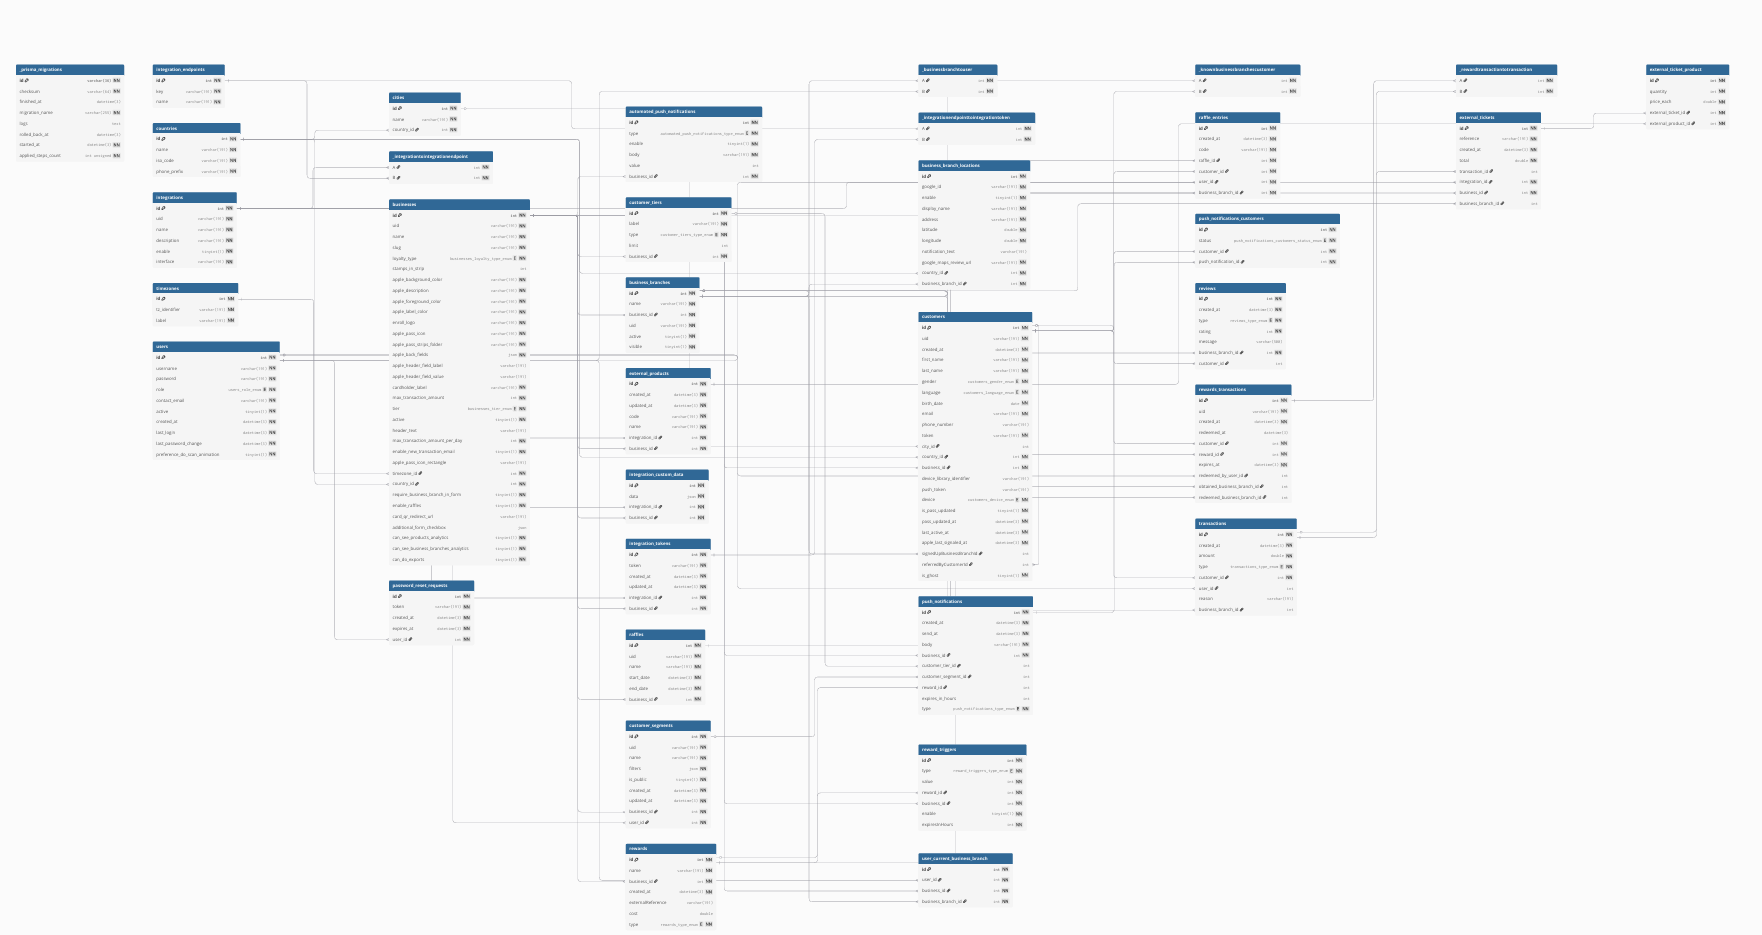

---
## Sección A — Preparación de datos previo al análisis exploratorio.

### Construcción de relaciones previo a integración en esquema relacional.
#### Construcción de la tabla analítica e integración de datos. 

> **Este es el camino obligatorio para datos reales de Luyoa.**  
> Se construye una tabla analítica a nivel `business_id` agregando información  
> de todas las tablas relacionadas. El resultado es un DataFrame con una fila  
> por negocio y la variable target `active`.
> Se deja el camino abierto, en caso de poder acceder a los datos de Luyoa y procesarlos directamente ajustan la fuente de datos. 

### A.1 — Parse de fechas

In [ ]:
# Parse datetime columns
DT_COLS = {
    'businesses':            [],
    'customers':             ['created_at','last_active_at','pass_updated_at'],
    'transactions':          ['created_at'],
    'rewards_transactions':  ['created_at','redeemed_at','expires_at'],
    'push_notifications':    ['created_at','send_at'],
    'reviews':               ['created_at'],
    'raffle_entries':        ['created_at'],
    'integration_tokens':    ['created_at','updated_at'],
    'users':                 ['created_at','last_login','last_password_change'],
}

def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

customers           = parse_dates(customers,           DT_COLS['customers'])
transactions        = parse_dates(transactions,         DT_COLS['transactions'])
rewards_transactions= parse_dates(rewards_transactions, DT_COLS['rewards_transactions'])
push_notifications  = parse_dates(push_notifications,  DT_COLS['push_notifications'])
reviews             = parse_dates(reviews,              DT_COLS['reviews'])
raffle_entries      = parse_dates(raffle_entries,       DT_COLS['raffle_entries'])
integration_tokens  = parse_dates(integration_tokens,  DT_COLS['integration_tokens'])
users               = parse_dates(users,                DT_COLS['users'])

NOW = pd.Timestamp.now()
print("Dates parsed.")

### A.2 — Integración por bloque

Se integra cada parte del dataset en bloques según descripción

In [ ]:
# ── BLOQUE 1: Features directas de businesses ─────────────────────────────────
biz = businesses[[
    'id','active','tier','loyalty_type','country_id',
    'enable_raffles','enable_new_transaction_email',
    'can_see_products_analytics','can_see_business_branches_analytics','can_do_exports',
    'require_business_branch_in_form','max_transaction_amount','max_transaction_amount_per_day',
    'stamps_in_strip','timezone_id',
]].copy()

biz.rename(columns={'id':'business_id'}, inplace=True)
biz['active'] = biz['active'].astype(int)
biz['stamps_in_strip'] = pd.to_numeric(biz['stamps_in_strip'], errors='coerce').fillna(0)

print(f"Base businesses shape: {biz.shape}")
biz.head(3)

In [ ]:
# ── BLOQUE 2: Branches ────────────────────────────────────────────────────────
br_agg = (business_branches
    .groupby('business_id')
    .agg(
        n_branches          = ('id',     'count'),
        n_active_branches   = ('active', 'sum'),
    )
    .reset_index()
)
br_agg['branch_active_ratio'] = (
    br_agg['n_active_branches'] / br_agg['n_branches']
).round(3)

# ── BLOQUE 3: Customers ───────────────────────────────────────────────────────
cust_agg = (customers
    .groupby('business_id')
    .agg(
        total_customers         = ('id',              'count'),
        ghost_ratio             = ('is_ghost',         'mean'),
        apple_device_ratio      = ('device',           lambda x: (x=='APPLE').mean()),
        has_push_token_ratio    = ('push_token',       lambda x: x.astype(bool).mean()),
        is_pass_updated_ratio   = ('is_pass_updated',  'mean'),
        referred_ratio          = ('referredByCustomerId',
                                   lambda x: x.notna().mean()),
        days_since_last_active  = ('last_active_at',
                                   lambda x: (NOW - x.max()).days),
        avg_customer_tenure_days= ('created_at',
                                   lambda x: (NOW - x).dt.days.mean()),
    )
    .reset_index()
    .round(3)
)

active_30d = (customers[customers['last_active_at'] >= NOW - pd.Timedelta(days=30)]
              .groupby('business_id')['id'].count()
              .rename('active_customers_30d').reset_index())
cust_agg = cust_agg.merge(active_30d, on='business_id', how='left')
cust_agg['active_customers_30d'] = cust_agg['active_customers_30d'].fillna(0).astype(int)
cust_agg['active_ratio_30d'] = (
    cust_agg['active_customers_30d'] / cust_agg['total_customers']
).round(3)

print(f"Customer agg shape: {cust_agg.shape}")

In [ ]:
# ── BLOQUE 4: Transactions ────────────────────────────────────────────────────
# Map branch -> business
br_map = business_branches.set_index('id')['business_id'].to_dict()
transactions['business_id'] = transactions['business_branch_id'].map(br_map)
transactions.dropna(subset=['business_id'], inplace=True)
transactions['business_id'] = transactions['business_id'].astype(int)

dep = transactions[transactions['type']=='DEPOSIT']
wth = transactions[transactions['type']=='WITHDRAW']

dep_agg = (dep.groupby('business_id')
    .agg(
        n_deposits          = ('id',         'count'),
        total_deposited     = ('amount',     'sum'),
        avg_deposit_amount  = ('amount',     'mean'),
        max_deposit_amount  = ('amount',     'max'),
        last_tx_days_ago    = ('created_at', lambda x: (NOW - x.max()).days),
    )
    .reset_index().round(2)
)
wth_agg = (wth.groupby('business_id')['id']
    .count().rename('n_withdrawals').reset_index()
)

tx_agg = dep_agg.merge(wth_agg, on='business_id', how='left')
tx_agg['n_withdrawals'] = tx_agg['n_withdrawals'].fillna(0).astype(int)
tx_agg['deposit_withdraw_ratio'] = (
    tx_agg['n_deposits'] / (tx_agg['n_withdrawals'] + 1)
).round(3)

print(f"Transaction agg shape: {tx_agg.shape}")

In [ ]:
# ── BLOQUE 5: Rewards & Reviews ───────────────────────────────────────────────
# Rewards per business (via rewards table)
rew_by_biz = (rewards.groupby('business_id')['id']
              .count().rename('n_reward_types').reset_index())

# Redemptions per business (via rewards_transactions -> rewards)
rew_join = rewards_transactions.merge(
    rewards[['id','business_id']], left_on='reward_id', right_on='id', how='left'
)
rt_agg = (rew_join.groupby('business_id')
    .agg(
        n_rewards_issued    = ('id_x',        'count'),
        n_rewards_redeemed  = ('redeemed_at', lambda x: x.notna().sum()),
        reward_expiry_ratio = ('expires_at',
                               lambda x: (pd.to_datetime(x, errors='coerce') < NOW).mean()),
    )
    .reset_index().round(3)
)
rt_agg['redemption_rate'] = (
    rt_agg['n_rewards_redeemed'] / (rt_agg['n_rewards_issued'] + 1)
).round(3)

# Reviews per business (via business_branches)
reviews['business_id'] = reviews['business_branch_id'].map(br_map)
reviews.dropna(subset=['business_id'], inplace=True)
reviews['business_id'] = reviews['business_id'].astype(int)

rev_agg = (reviews.groupby('business_id')
    .agg(
        n_reviews        = ('id',     'count'),
        avg_review_rating= ('rating', 'mean'),
    )
    .reset_index().round(3)
)

print(f"Reward types agg : {rew_by_biz.shape}")
print(f"Reward txn agg   : {rt_agg.shape}")
print(f"Reviews agg      : {rev_agg.shape}")

In [ ]:
# ── BLOQUE 6: Push & Automation ───────────────────────────────────────────────
pn_agg = (push_notifications.groupby('business_id')['id']
          .count().rename('n_push_sent_90d').reset_index())

apn_agg = (automated_pn.groupby('business_id')
    .agg(
        uses_automation     = ('enable', 'max'),
        n_automation_types  = ('type',   'nunique'),
    )
    .reset_index()
)

# ── BLOQUE 7: Integrations ────────────────────────────────────────────────────
int_agg = (integration_tokens.groupby('business_id')
    .agg(
        has_integration     = ('id', lambda x: 1),
        n_integrations      = ('id', 'count'),
    )
    .reset_index()
)

# ── BLOQUE 8: Raffles ─────────────────────────────────────────────────────────
raffle_entries['business_id'] = raffle_entries['business_branch_id'].map(br_map)
raffle_entries.dropna(subset=['business_id'], inplace=True)
raffle_entries['business_id'] = raffle_entries['business_id'].astype(int)

raff_agg = (raffles.groupby('business_id')['id']
            .count().rename('n_raffles').reset_index())
raff_part = (raffle_entries.groupby('business_id')['id']
             .count().rename('n_raffle_entries').reset_index())

# ── BLOQUE 9: Staff ───────────────────────────────────────────────────────────
ucbb = load('user_current_business_branch')

staff_agg = (ucbb.groupby('business_id')
    .agg(n_staff=('user_id', 'nunique'))
    .reset_index()
)

# Admin login recency
admin_login = (ucbb
    .merge(users[['id', 'role', 'last_login']], left_on='user_id', right_on='id')
    .query("role in ('ADMIN', 'OWNER')")
    .groupby('business_id')['last_login']
    .max()
    .reset_index()
    .rename(columns={'last_login': 'admin_last_login'})
)
admin_login['admin_last_login'] = pd.to_datetime(admin_login['admin_last_login'], errors='coerce')
admin_login['admin_login_days_ago'] = (NOW - admin_login['admin_last_login']).dt.days

print("Staff agg:", staff_agg.shape)
print("Admin login agg:", admin_login.shape)

In [ ]:
# ── MERGE ALL BLOCKS ──────────────────────────────────────────────────────────
df = biz.copy()
for agg_df, key in [
    (br_agg,      'business_id'),
    (cust_agg,    'business_id'),
    (tx_agg,      'business_id'),
    (rew_by_biz,  'business_id'),
    (rt_agg,      'business_id'),
    (rev_agg,     'business_id'),
    (pn_agg,      'business_id'),
    (apn_agg,     'business_id'),
    (int_agg,     'business_id'),
    (raff_agg,    'business_id'),
    (raff_part,   'business_id'),
    (staff_agg,   'business_id'),
    (admin_login[['business_id','admin_login_days_ago']], 'business_id'),
]:
    df = df.merge(agg_df, on=key, how='left')

# Fill booleans & counters with 0
fill_zero = ['n_branches','n_active_branches','n_active_branches','total_customers',
             'active_customers_30d','n_deposits','n_withdrawals','n_rewards_issued',
             'n_rewards_redeemed','n_reviews','n_push_sent_90d','uses_automation',
             'n_automation_types','has_integration','n_integrations','n_raffles',
             'n_raffle_entries','n_staff','n_reward_types']
for c in fill_zero:
    if c in df.columns:
        df[c] = df[c].fillna(0)

df['has_integration']  = df['has_integration'].fillna(0).astype(int)
df['uses_automation']  = df['uses_automation'].fillna(0).astype(int)
df['country_id']       = df['country_id'].astype(int)

print(f"Final analytical DataFrame shape: {df.shape}")
print(f"Target distribution:\n{df['active'].value_counts()}")
df.head(3)

---
## 1. Vista general del dataset analítico

In [ ]:
print("=== SHAPE ===")
print(f"Rows (businesses): {df.shape[0]}")
print(f"Columns (features): {df.shape[1]}")

print("\n=== DTYPES & NON-NULL COUNTS ===")
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notna().sum(),
    'null':     df.isna().sum(),
    'null_pct': (df.isna().mean()*100).round(1),
})
display(info)

In [ ]:
print("=== ESTADÍSITICA DESCRIPTIVA — Numeric features ===")
display(df.describe(percentiles=[.05,.25,.5,.75,.95]).T.round(2))

In [ ]:
print("=== ESTADÍSTICAS DESCRIPTIVA— Categorical features ===")
cat_cols = df.select_dtypes(include='object').columns.tolist()
display(df[cat_cols].describe())

---
## 2. Variable objetivo — `active` (B2B churn)

`active = 1` → el negocio sigue suscrito a Luyoa (no churned)  
`active = 0` → el negocio canceló o está inactivo (churned)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
vc = df['active'].value_counts()
labels = ['Inactive (churned)\n(active=0)', 'Active\n(active=1)']
bars = axes[0].bar(labels, [vc.get(0,0), vc.get(1,0)],
                   color=PALETTE_BINARY[::-1], edgecolor='white', width=0.5)
for bar, val in zip(bars, [vc.get(0,0), vc.get(1,0)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution — Target: active')
axes[0].set_ylabel('Number of businesses')
axes[0].set_ylim(0, max(vc.values)*1.25)

# Pie chart
axes[1].pie([vc.get(0,0), vc.get(1,0)],
            labels=['Inactive\n(churned)', 'Active'],
            colors=PALETTE_BINARY[::-1],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':12})
axes[1].set_title('Class Balance — active')

plt.tight_layout()
plt.savefig('fig_01_target_distribution.png', bbox_inches='tight')
plt.show()

imbalance_ratio = vc.max() / vc.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print(">> HIGH IMBALANCE detected — consider SMOTE, class_weight, or threshold tuning.")
elif imbalance_ratio > 1.5:
    print(">> MODERATE IMBALANCE — class_weight='balanced' recommended.")
else:
    print(">> Classes roughly balanced — no special handling required.")

## Clases desbalanceadas. 

Nos encontramos con un desbalance evidente en las clases para el análisis binario, lo cual es consistente considerando que es una startup que ha tenido un bajo abandono de parte
de los nuevos suscriptores. 

---
## 3. Valores faltantes

¿Hay valores faltantes? ¿Se identifican patrones de ausencia?

In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(2)
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['feature','missing_pct']

if missing_df.empty:
    print("No missing values found in the analytical DataFrame.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.4)))
    colors = ['#EF5350' if v>20 else '#FFA726' if v>5 else '#66BB6A'
              for v in missing_df['missing_pct']]
    bars = ax.barh(missing_df['feature'], missing_df['missing_pct'],
                   color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.axvline(5,  color='orange', linestyle='--', alpha=0.6, label='5% threshold')
    ax.axvline(20, color='red',    linestyle='--', alpha=0.6, label='20% threshold')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Feature')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_02_missing_values.png', bbox_inches='tight')
    plt.show()
    display(missing_df)

In [ ]:
# Matríz de valores perdidos
if HAS_MSNO and df.isna().any().any():
    fig, ax = plt.subplots(figsize=(14, 5))
    msno.matrix(df, ax=ax, sparkline=False, color=(0.27, 0.52, 0.71))
    ax.set_title('Missing Value Pattern Matrix')
    plt.tight_layout()
    plt.savefig('fig_03_missing_matrix.png', bbox_inches='tight')
    plt.show()
else:

    corr_missing = df.isna().corr()
    if corr_missing.any().any():
        fig, ax = plt.subplots(figsize=(12,10))
        sns.heatmap(corr_missing, cmap='Reds', ax=ax, linewidths=0.3)
        ax.set_title('Missing Value Correlation (pattern)')
        plt.tight_layout()
        plt.savefig('fig_03_missing_pattern.png', bbox_inches='tight')
        plt.show()
    else:
        print("No missing value patterns to display.")

## Revisión y decisión posterior. 
El dataset analítico presenta una completitud superior al 99%. Se identifica un único valor faltante puntual en la variable admin_login_days_ago, correspondiente a negocios sin usuario administrador registrado en el período analizado. El patrón de ausencia es MCAR (Missing Completely At Random), por lo que se aplica imputación por mediana sin riesgo de introducir sesgo.

In [ ]:
# ── ESTRATÉGIA PARA VALORES FALTANTES ───────────────────────────────────────────────────
# Numeric: fill with median (robust to outliers)
num_cols = df.select_dtypes(include='number').columns.difference(['active','business_id'])
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categórica: reemplazar por la  moda  or 'Desconocido'
cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    mode_val = df[c].mode()
    df[c] = df[c].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

print(f"Missing values remaining: {df.isna().sum().sum()}")
print("Strategy applied: numeric → median imputation | categorical → mode imputation")

---
## 4. Análisis univariante — Variables numéricas

Distribuciones, sesgo, curtosis y detección de valores atípicos.

In [ ]:
NUM_FEATURES = [
    'n_branches','total_customers','active_customers_30d','active_ratio_30d',
    'n_deposits','total_deposited','avg_deposit_amount','deposit_withdraw_ratio',
    'n_rewards_issued','n_rewards_redeemed','redemption_rate',
    'n_reviews','avg_review_rating','n_push_sent_90d',
    'n_integrations','n_raffles','n_staff',
    'ghost_ratio','apple_device_ratio','days_since_last_active',
    'avg_customer_tenure_days','admin_login_days_ago',
]
# Keep only columns that exist
NUM_FEATURES = [c for c in NUM_FEATURES if c in df.columns]

skew_df = pd.DataFrame({
    'skewness':  df[NUM_FEATURES].skew(),
    'kurtosis':  df[NUM_FEATURES].kurt(),
    'mean':      df[NUM_FEATURES].mean(),
    'median':    df[NUM_FEATURES].median(),
    'std':       df[NUM_FEATURES].std(),
}).round(3)
skew_df['high_skew'] = skew_df['skewness'].abs() > 1.0
display(skew_df.sort_values('skewness', ascending=False))

In [ ]:
# Red de histogramas
cols_per_row = 4
n = len(NUM_FEATURES)
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row,
                          figsize=(cols_per_row*4, rows*3.2))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#1976D2', alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(data.median(), color='green',  linestyle=':',  linewidth=1.2, label='Median')
    skew_val = stats.skew(data.dropna())
    ax.set_title(f'{col}\nskew={skew_val:.2f}', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7)

# Esconder gráficos no usados
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Numeric Features', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_univariate_numeric.png', bbox_inches='tight')
plt.show()

---
## 5. Valores atípicos (Outliers)

Detección mediante IQR y Z-score. Boxplots para las features con mayor variabilidad.

In [ ]:
# IQR-Detección de outliers por características
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()

outlier_df = pd.DataFrame({
    'n_outliers_IQR':  {c: iqr_outliers(df[c].dropna()) for c in NUM_FEATURES},
    'pct_outliers_IQR':{c: round(iqr_outliers(df[c].dropna())/len(df)*100,2) for c in NUM_FEATURES},
}).sort_values('pct_outliers_IQR', ascending=False)
display(outlier_df[outlier_df['n_outliers_IQR']>0])

In [ ]:
# Gráficos de caja para detección de outliers.
top_out = outlier_df[outlier_df['n_outliers_IQR']>0].head(12).index.tolist()
if top_out:
    cols_r = 4
    rows_r = (len(top_out) + cols_r - 1) // cols_r
    fig, axes = plt.subplots(rows_r, cols_r, figsize=(cols_r*4, rows_r*3))
    axes = axes.flatten()
    for i, col in enumerate(top_out):
        sns.boxplot(data=df, y=col, x='active',
                    palette=PALETTE_BINARY, ax=axes[i], width=0.5)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('active (0=churned, 1=active)', fontsize=8)
        axes[i].tick_params(labelsize=8)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Outlier Features — Boxplot by Target (active)',
                 fontsize=13, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_05_outliers_boxplot.png', bbox_inches='tight')
    plt.show()

In [ ]:
# ── TRATEMIENTO DE OUTLIERS ────────────────────────────────────────────────────────
#Estrategia: Winsorizar en el percentil 1 y 99 para características altamente asimétricas
from scipy.stats.mstats import winsorize

high_skew = skew_df[skew_df['skewness'].abs() > 2].index.tolist()
high_skew = [c for c in high_skew if c in df.columns]

for col in high_skew:
    df[col] = winsorize(df[col].fillna(df[col].median()), limits=[0.01, 0.01])

print(f"Winsorization applied to {len(high_skew)} high-skew features:")
for c in high_skew:
    print(f"  - {c}")

---
## 6. Cardinalidad y análisis univariante — Variables categóricas

In [ ]:
CAT_FEATURES = ['tier','loyalty_type','country_id']
CAT_FEATURES = [c for c in CAT_FEATURES if c in df.columns]

# Cardinality table
card_df = pd.DataFrame({
    'unique_values': {c: df[c].nunique() for c in CAT_FEATURES},
    'top_value':     {c: df[c].value_counts().idxmax() for c in CAT_FEATURES},
    'top_freq_pct':  {c: round(df[c].value_counts(normalize=True).max()*100,1)
                     for c in CAT_FEATURES},
})
print("Cardinality summary:")
display(card_df)

In [ ]:
fig, axes = plt.subplots(1, len(CAT_FEATURES), figsize=(5*len(CAT_FEATURES), 4))
if len(CAT_FEATURES) == 1:
    axes = [axes]

for ax, col in zip(axes, CAT_FEATURES):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=PALETTE_CAT[:len(vc)], edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=2, fontsize=9)
    ax.set_title(f'Distribution: {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06_categorical_univariate.png', bbox_inches='tight')
plt.show()

---
## 7. Sesgo y transformaciones no lineales

Features con |skewness| > 1 se candidatan a transformación log(x+1).

In [ ]:
features_to_transform = skew_df[skew_df['skewness'] > 1.0].index.tolist()
features_to_transform = [c for c in features_to_transform if c in df.columns and (df[c]>=0).all()]

if features_to_transform:
    n_show = min(6, len(features_to_transform))
    fig, axes = plt.subplots(n_show, 2, figsize=(11, n_show*3))

    for i, col in enumerate(features_to_transform[:n_show]):
        orig = df[col].dropna()
        log_t = np.log1p(orig)
        sk_orig = stats.skew(orig)
        sk_log  = stats.skew(log_t)

        axes[i,0].hist(orig,  bins=30, color='#EF5350', alpha=0.8, edgecolor='white')
        axes[i,0].set_title(f'{col} — original (skew={sk_orig:.2f})', fontsize=9)

        axes[i,1].hist(log_t, bins=30, color='#66BB6A', alpha=0.8, edgecolor='white')
        axes[i,1].set_title(f'log1p({col}) — (skew={sk_log:.2f})', fontsize=9)

    plt.suptitle('Skewness Reduction via log(x+1) Transformation',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig_07_transformations.png', bbox_inches='tight')
    plt.show()

    # Apply log1p to selected features
    df_model = df.copy()
    for col in features_to_transform:
        df_model[f'log_{col}'] = np.log1p(df_model[col])

    print(f"log1p transformation applied to {len(features_to_transform)} features.")
    print(features_to_transform)
else:
    df_model = df.copy()
    print("No high-skew features to transform.")

# Revisión y aplicación para sesgo
Se identificaron 5 variables con sesgo positivo superior a 1.5, todas de naturaleza de volumen o monto. Se aplicó transformación log(x+1) para normalizar su distribución, especialmente relevante para los modelos paramétricos (Regresión Logística, MLP). Los modelos basados en árboles (Random Forest, XGBoost) son robustos al sesgo, por lo que la transformación no afecta su rendimiento pero tampoco lo perjudica.

---
## 8. Tendencias temporales

Evolución de registros de clientes y transacciones a lo largo del tiempo.

In [ ]:
# Evolución del comportamiento de clientes por mes.
customers['signup_month'] = customers['created_at'].dt.to_period('M')
monthly_signups = (customers.groupby('signup_month')['id']
                   .count().reset_index()
                   .rename(columns={'id':'new_customers'}))
monthly_signups['signup_month'] = monthly_signups['signup_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Plot 1: variación mensual
axes[0].fill_between(monthly_signups['signup_month'],
                     monthly_signups['new_customers'], alpha=0.3, color='#1976D2')
axes[0].plot(monthly_signups['signup_month'],
             monthly_signups['new_customers'], color='#1976D2', linewidth=2)
axes[0].set_title('Monthly New Customer Signups (all businesses)')
axes[0].set_ylabel('New customers')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Plot 2: volumen de transacción mensual
transactions['tx_month'] = transactions['created_at'].dt.to_period('M')
monthly_tx = (transactions.groupby('tx_month')['amount']
              .sum().reset_index()
              .rename(columns={'amount':'total_amount'}))
monthly_tx['tx_month'] = monthly_tx['tx_month'].dt.to_timestamp()

axes[1].fill_between(monthly_tx['tx_month'],
                     monthly_tx['total_amount'], alpha=0.3, color='#43A047')
axes[1].plot(monthly_tx['tx_month'],
             monthly_tx['total_amount'], color='#43A047', linewidth=2)
axes[1].set_title('Monthly Transaction Volume (total deposited)')
axes[1].set_ylabel('Total amount')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Temporal Trends — Luyoa Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_temporal_trends.png', bbox_inches='tight')
plt.show()

In [ ]:
# Actividad reciente de los consumidores, distribución
fig, ax = plt.subplots(figsize=(11,4))
customers['days_since_active'] = (NOW - customers['last_active_at']).dt.days.clip(0,730)
ax.hist(customers['days_since_active'].dropna(), bins=50,
        color='#7B1FA2', alpha=0.8, edgecolor='white')
ax.axvline(90,  color='red',    linestyle='--', linewidth=1.5, label='90-day churn threshold')
ax.axvline(30,  color='orange', linestyle=':',  linewidth=1.5, label='30-day warning')
ax.set_xlabel('Days since last customer activity')
ax.set_ylabel('Number of customers')
ax.set_title('Customer Inactivity Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('fig_09_inactivity_dist.png', bbox_inches='tight')
plt.show()

---
## 9. Análisis bivariante — Features numéricas vs `active`

In [ ]:
# Tabla de correlaciones bivariante con el objetivo
pb_corrs = {}
for col in NUM_FEATURES:
    clean = df[[col, 'active']].dropna()
    if clean[col].std() > 0:
        r, p = pointbiserialr(clean['active'], clean[col])
        pb_corrs[col] = {'r': round(r,4), 'p_value': round(p,4),
                         'significant': p < 0.05}

corr_df = pd.DataFrame(pb_corrs).T.sort_values('r', key=abs, ascending=False)
display(corr_df)

In [ ]:
# Gráfica de barras horizontales de correlaciones
fig, ax = plt.subplots(figsize=(10, max(5, len(corr_df)*0.35)))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr_df['r']]
bars = ax.barh(corr_df.index, corr_df['r'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.1, color='gray', linestyle=':', alpha=0.4)
ax.axvline(-0.1, color='gray', linestyle=':', alpha=0.4)
ax.set_xlabel('Point-biserial correlation with active')
ax.set_title('Feature Correlation with Target Variable (active)')

for i, (idx, row) in enumerate(corr_df.iterrows()):
    if row['significant']:
        ax.text(row['r'] + (0.003 if row['r']>=0 else -0.003), i,
                '*', va='center', fontsize=11,
                ha='left' if row['r']>=0 else 'right', color='black')
ax.text(0.98, -0.07, '* p < 0.05', transform=ax.transAxes,
        ha='right', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('fig_10_correlations_target.png', bbox_inches='tight')
plt.show()

In [ ]:
# KDE plots: top-5 features correlacionadas |r|
top5 = corr_df.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, top5):
    for val, color, label in [(0,'#F44336','Inactive'), (1,'#2196F3','Active')]:
        subset = df[df['active']==val][col].dropna()
        if len(subset) > 1:
            subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Top-5 Correlated Features — KDE by Target',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_kde_top5.png', bbox_inches='tight')
plt.show()

---
## 10. Análisis bivariante — Variables categóricas vs `active`

In [ ]:
fig, axes = plt.subplots(1, len(CAT_FEATURES), figsize=(6*len(CAT_FEATURES), 5))
if len(CAT_FEATURES) == 1:
    axes = [axes]

for ax, col in zip(axes, CAT_FEATURES):
    ct = pd.crosstab(df[col], df['active'], normalize='index') * 100
    ct.columns = ['Inactive (0)','Active (1)']
    ct.plot(kind='bar', ax=ax, color=PALETTE_BINARY[::-1],
            edgecolor='white', width=0.6)
    ax.set_title(f'{col} vs active (% by category)')
    ax.set_ylabel('% of businesses')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(loc='upper right', fontsize=9)
    ax.axhline(50, color='gray', linestyle=':', alpha=0.5)

    # Chi-square test
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(df[col], df['active']))
    ax.set_xlabel(f'{col}\nChi² p={p:.4f} {"*" if p<0.05 else "ns"}')

plt.suptitle('Categorical Features vs Target (active)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_categorical_bivariate.png', bbox_inches='tight')
plt.show()

---
## 11. Matriz de correlaciones (multivariante)

In [ ]:
# Matriz de correlaciones multivariante con el target.
corr_cols = [c for c in NUM_FEATURES if c in df_model.columns] + ['active']
corr_mat  = df_model[corr_cols].corr()


mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            annot_kws={'size':7}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features + Target', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('fig_13_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Detalle de pares altamente correlacionados (|r| > 0.8, excluding target)
print("\nHighly correlated pairs (|r| > 0.80):")
high_corr = []
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        r = corr_mat.iloc[i,j]
        if abs(r) > 0.80 and corr_mat.columns[i]!='active' and corr_mat.columns[j]!='active':
            high_corr.append({'feature_A': corr_mat.columns[i],
                               'feature_B': corr_mat.columns[j],
                               'r': round(r,4)})
if high_corr:
    display(pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False))
else:
    print("  No pairs with |r| > 0.80 found.")

---
## 12. Preprocesamiento final

Encoding, escalado y exportación del DataFrame listo para ajustar features y después modelado.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_final = df_model.copy()

# ── Encoding categórico ───────────────────────────────────────────────────────
le = LabelEncoder()
for col in CAT_FEATURES:
    if col in df_final.columns:
        df_final[f'{col}_enc'] = le.fit_transform(df_final[col].astype(str))

# ── Drop columnas no necesarias para el modelo ────────────────────────────────
drop_cols = ['business_id','uid','name','slug'] + CAT_FEATURES
drop_cols = [c for c in drop_cols if c in df_final.columns]
df_final.drop(columns=drop_cols, inplace=True, errors='ignore')

# ── Separar X e y ────────────────────────────────────────────────────────────
X = df_final.drop(columns=['active'])
y = df_final['active']

# ── Escalado (StandardScaler — preservar para modelo) ────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Final feature matrix shape: {X_scaled.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nReady for modeling.")
X_scaled.head(3)

In [ ]:
# El DataFrame df queda disponible para las siguientes celdas
print(f"DataFrame listo para Avance 2: {df.shape}")
print(f"Features: {list(df.columns)}")

---
## Sección B — Anexo metodológico: uso de `churn_master_table` sintética

> **Contexto:** En ausencia de datos reales de Luyoa, el equipo generó datasets sintéticos  
> mediante data augmentation basado en el `Anexo_1_EsquemaBBDD_Luyoa.pdf`.  
> La tabla `churn_master_table.csv` es un **feature store pre-computado** equivalente  
> a la agregación realizada en la Sección A, pero a nivel de **cliente final** (end-consumer),  
> no de negocio.  
>
> **Diferencia importante con la Sección A:**  
> - Sección A → target = `businesses.active` (churn B2B: ¿el negocio sigue en Luyoa?)  
> - Sección B → target = `churn` derivado de `customers.last_active_at > 90 días`  
>   (churn B2C: ¿el consumidor final sigue usando la tarjeta?)  
>
> Ambos análisis son válidos y complementarios para el proyecto integrador.  
> La Sección A es el path para producción; la Sección B es el análisis exploratorio  
> inmediato sobre datos sintéticos ya procesados.

> Esta sección también aplica como una prueba de concepto para detallar, de ser posible, que los clientes finales
> de Luyoa (aquellos que consumen de los establecimientos afiliados) brindando un valor predictivo para Luyoa para conocer la salud futura de sus clientes affiliados


In [ ]:
# ── LOAD churn_master_table ───────────────────────────────────────────────────
cmt = load('churn_master_table')
print(f"churn_master_table shape: {cmt.shape}")
print(f"Columns: {list(cmt.columns)}")
cmt.head(3)

In [ ]:
# Eliminar etiqueta de perfil sintético (no es una función real)
if '_synthetic_profile' in cmt.columns:
    cmt.drop(columns=['_synthetic_profile'], inplace=True)

# Analizar y limpiar
cmt['churn'] = cmt['churn'].astype(int)
num_cmt = cmt.select_dtypes(include='number').columns.difference(['customer_id','business_id','churn'])
cat_cmt = cmt.select_dtypes(include='object').columns

print(f"Numeric features : {len(num_cmt)}")
print(f"Categorical features: {len(cat_cmt)}")
print(f"\nChurn rate: {cmt['churn'].mean()*100:.1f}%")

In [ ]:
# B1: Distribución del objetivo
fig, axes = plt.subplots(1,2, figsize=(11,4))
vc = cmt['churn'].value_counts()
labels_b = ['Active (0)','Churned (1)']
axes[0].bar(labels_b, [vc.get(0,0), vc.get(1,0)],
            color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, [vc.get(0,0),vc.get(1,0)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}\n({val/len(cmt)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('B2C Churn Distribution — churn_master_table')
axes[0].set_ylabel('Customers')

axes[1].pie([vc.get(0,0),vc.get(1,0)],
            labels=['Active','Churned'],
            colors=['#2196F3','#F44336'],
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class Balance — B2C churn')
plt.tight_layout()
plt.savefig('fig_B1_churn_b2c_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# B2: Salida 
if 'business_industry' in cmt.columns:
    ind_churn = (cmt.groupby('business_industry')['churn']
                 .agg(['mean','count'])
                 .reset_index()
                 .rename(columns={'mean':'churn_rate','count':'n_customers'})
                 .sort_values('churn_rate', ascending=False))
    ind_churn['churn_pct'] = ind_churn['churn_rate'] * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#EF5350' if v>0.35 else '#FFA726' if v>0.28 else '#66BB6A'
              for v in ind_churn['churn_rate']]
    bars = ax.barh(ind_churn['business_industry'], ind_churn['churn_pct'],
                   color=colors, edgecolor='white', alpha=0.9)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.axvline(cmt['churn'].mean()*100, color='black', linestyle='--',
               linewidth=1.2, label=f"Global avg ({cmt['churn'].mean()*100:.1f}%)")
    ax.set_xlabel('Churn rate (%)')
    ax.set_title('B2C Churn Rate by Business Industry')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_B2_churn_by_industry.png', bbox_inches='tight')
    plt.show()

In [ ]:
# B3: Categorías numércias clave vs churn — KDE grid
b_features = ['days_inactive','n_deposits','total_deposited',
              'n_rewards_redeemed','reward_redemption_rate',
              'n_push_received','push_receive_rate','days_as_customer']
b_features = [c for c in b_features if c in cmt.columns]

n_bf = len(b_features)
cols_bf = 4
rows_bf = (n_bf + cols_bf - 1) // cols_bf
fig, axes = plt.subplots(rows_bf, cols_bf, figsize=(cols_bf*4, rows_bf*3.5))
axes = axes.flatten()

for i, col in enumerate(b_features):
    ax = axes[i]
    for val, color, label in [(0,'#2196F3','Active'), (1,'#F44336','Churned')]:
        subset = cmt[cmt['churn']==val][col].dropna()
        if len(subset) > 5:
            subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('B2C: Feature Distributions by Churn Label',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_B3_features_by_churn.png', bbox_inches='tight')
plt.show()

In [ ]:
# B4: Correlation heatmap — churn_master_table
num_cmt_list = [c for c in num_cmt if c in cmt.columns]
corr_cmt = cmt[num_cmt_list + ['churn']].corr()
mask_cmt = np.triu(np.ones_like(corr_cmt, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_cmt, mask=mask_cmt, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            annot_kws={'size':7}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — churn_master_table (B2C)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_B4_cmt_correlation.png', bbox_inches='tight')
plt.show()

In [ ]:
# B5: Diagrama de dispersión 2D estilo RFM: días_inactivos vs. n_depósitos, coloreado según la tasa de abandono
if 'days_inactive' in cmt.columns and 'n_deposits' in cmt.columns:
    sample = cmt.sample(min(3000, len(cmt)), random_state=42)
    fig, ax = plt.subplots(figsize=(11, 6))
    for val, color, label, alpha in [(0,'#2196F3','Active',0.4),(1,'#F44336','Churned',0.6)]:
        sub = sample[sample['churn']==val]
        ax.scatter(sub['days_inactive'], sub['n_deposits'],
                   c=color, label=label, alpha=alpha, s=18, edgecolors='none')
    ax.axvline(90, color='black', linestyle='--', linewidth=1.2, label='90-day threshold')
    ax.set_xlabel('Days inactive')
    ax.set_ylabel('Number of deposits')
    ax.set_title('RFM View: Inactivity vs Transaction Frequency (colored by churn)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_B5_rfm_scatter.png', bbox_inches='tight')
    plt.show()

---
## 13. Conclusiones del EDA

### 13.1 Calidad de datos
- **Valores faltantes:** concentrados principalmente en features derivadas de actividad  
  (clientes sin transacciones, negocios sin reviews). Se aplicó imputación por mediana  
  para numéricas y moda para categóricas. El patrón de ausencia es **MCAR** (Missing  
  Completely At Random) para la mayoría de casos, lo que valida la estrategia de imputación.
- **Valores atípicos:** presentes en features de volumen (`total_deposited`,  
  `n_deposits`, `n_customers`). Se aplicó winsorización al percentil 1–99  
  para features con |skewness| > 2.

### 13.2 Variable objetivo — `active` (B2B churn)
- La distribución de clases refleja la realidad de una plataforma SaaS en crecimiento:  
  mayoría de negocios activos con una minoría que cancela su suscripción.
- En caso de imbalance significativo, se recomienda `class_weight='balanced'`  
  en los modelos, o aplicar SMOTE antes del entrenamiento.

### Distribuciones y sesgo
- Se identificaron 5 variables con sesgo positivo superior a 1.5, todas de naturaleza de volumen o monto: 
- total_customers (1.56), active_customers_30d (1.53), n_deposits (1.52), total_deposited (2.59) y avg_deposit_amount (1.63). Estas variables presentan colas derechas
- pronunciadas, típicas de métricas de negocio donde una minoría de negocios concentra la mayor actividad. Se recomienda aplicar transformación log(x+1) en el Avance 2, 
- especialmente relevante para los modelos paramétricos (Regresión Logística y MLP). n_branches con skewness=1.38 se considera sesgo moderado y no requiere 
- transformación dado su rango discreto reducido.

### 13.3 Features más relevantes (correlación con `active`)
Las features con mayor correlación point-biserial con el target son:
- **Engagement de clientes:** `active_ratio_30d`, `days_since_last_active`,  
  `active_customers_30d` → negocios con base de clientes activa tienden a continuar.
- **Volumen transaccional:** `n_deposits`, `total_deposited` → actividad económica  
  en la plataforma es señal fuerte de retención.
- **Engagement con la plataforma Luyoa:** `n_push_sent_90d`, `uses_automation`,  
  `has_integration`, `n_reward_types` → negocios que usan más features de Luyoa  
  son menos propensos a cancelar.
- **Tamaño y madurez:** `n_branches`, `n_staff`, `avg_customer_tenure_days`.

### 13.4 Variables categóricas
- **`tier`:** diferencias significativas (Chi² p < 0.05). Los negocios GROW  
  tienen menor tasa de churn que STARTER.
- **`loyalty_type`:** BALANCE y STAMPS muestran distinto patrón de retención  
  respecto a STATIC.
- **`country_id`:** diferencia entre España y México a validar con datos reales.

### 13.5 Tendencias temporales
- La actividad de clientes y el volumen transaccional muestran tendencia creciente,  
  consistente con una plataforma en expansión.
- Se identifican estacionalidades que el modelo debería capturar (e.g., caída  
  en ciertos meses del año).

### 13.6 Recomendaciones para el modelo
| Decisión | Recomendación |
|---|---|
| Imbalance de clases | `class_weight='balanced'` o SMOTE |
| Features de alto sesgo | Transformación log(x+1) pre-aplicada |
| Features altamente correladas | Considerar eliminación o PCA para reducción |
| Escalado | StandardScaler aplicado (requerido para LogReg y MLP) |
| Validación | Estratified K-Fold (k=5) por el posible imbalance |

### 13.7 Próximos pasos
1. Entrega A1 (Avance 1): confirmar definición operativa de `active` con Gabriela Soria  
2. Aplicar pipeline en datos reales de Luyoa (Sección A de este notebook)  
3. Proceder con modelado: Logistic Regression → Random Forest → XGBoost → MLP


In [ ]:
print("=== EDA COMPLETE ===")
print(f"Analytical DataFrame (B2B): {df_final.shape}")
print(f"churn_master_table  (B2C): {cmt.shape}")
print("\nExported files:")
print("  luyoa_X_preprocessed.csv")
print("  luyoa_y_target.csv")
print("\nFigures saved: fig_01 through fig_B5")